In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)
df.to_csv("data/compas-scores-two-years.csv", index=False) #local path for raw dataset
print(df.shape)

(7214, 53)


In [3]:
print(df.info())       #column types, non-null included

<class 'pandas.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   str    
 2   first                    7214 non-null   str    
 3   last                     7214 non-null   str    
 4   compas_screening_date    7214 non-null   str    
 5   sex                      7214 non-null   str    
 6   dob                      7214 non-null   str    
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   str    
 9   race                     7214 non-null   str    
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count             7214 non-n

In [4]:
print(df.head(10))         #display first 10 rows

   id                name      first         last compas_screening_date     sex         dob  age          age_cat  \
0   1    miguel hernandez     miguel    hernandez            2013-08-14    Male  1947-04-18   69  Greater than 45   
1   3         kevon dixon      kevon        dixon            2013-01-27    Male  1982-01-22   34          25 - 45   
2   4            ed philo         ed        philo            2013-04-14    Male  1991-05-14   24     Less than 25   
3   5         marcu brown      marcu        brown            2013-01-13    Male  1993-01-21   23     Less than 25   
4   6  bouthy pierrelouis     bouthy  pierrelouis            2013-03-26    Male  1973-01-22   43          25 - 45   
5   7        marsha miles     marsha        miles            2013-11-30    Male  1971-08-22   44          25 - 45   
6   8       edward riddle     edward       riddle            2014-02-19    Male  1974-07-23   41          25 - 45   
7   9      steven stewart     steven      stewart            201

In [5]:
print(df.describe())       #summary stats for numeric columns

                 id          age  juv_fel_count  decile_score  juv_misd_count  juv_other_count  priors_count  \
count   7214.000000  7214.000000    7214.000000   7214.000000     7214.000000      7214.000000   7214.000000   
mean    5501.255753    34.817993       0.067230      4.509565        0.090934         0.109371      3.472415   
std     3175.706870    11.888922       0.473972      2.856396        0.485239         0.501586      4.882538   
min        1.000000    18.000000       0.000000      1.000000        0.000000         0.000000      0.000000   
25%     2735.250000    25.000000       0.000000      2.000000        0.000000         0.000000      0.000000   
50%     5509.500000    31.000000       0.000000      4.000000        0.000000         0.000000      2.000000   
75%     8246.500000    42.000000       0.000000      7.000000        0.000000         0.000000      5.000000   
max    11001.000000    96.000000      20.000000     10.000000       13.000000        17.000000     38.00

In [6]:
print(df['race'].value_counts())  #count of each race category

race
African-American    3696
Caucasian           2454
Hispanic             637
Other                377
Asian                 32
Native American       18
Name: count, dtype: int64


In [7]:
print(df['score_text'].value_counts())      # Low-Medium-High COMPAS risk scale

score_text
Low       3897
Medium    1914
High      1403
Name: count, dtype: int64


In [8]:
print(df['two_year_recid'].value_counts())  # variable: did they reoffend within 2 years?

two_year_recid
0    3963
1    3251
Name: count, dtype: int64


In [9]:
pd.crosstab(df['race'], df['score_text'], normalize='index')

score_text,High,Low,Medium
race,,,
African-American,0.277327,0.411797,0.310877
Asian,0.093750,0.750000,0.156250
Caucasian,0.112469,0.651997,0.235534
Hispanic,0.105181,0.701727,0.193093
Native American,0.333333,0.333333,0.333333
Other,0.068966,0.790451,0.140584


In [10]:
df['age'].describe()

count    7214.000000
mean       34.817993
std        11.888922
min        18.000000
25%        25.000000
50%        31.000000
75%        42.000000
max        96.000000
Name: age, dtype: float64

In [11]:
df['priors_count'].describe()

count    7214.000000
mean        3.472415
std         4.882538
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max        38.000000
Name: priors_count, dtype: float64

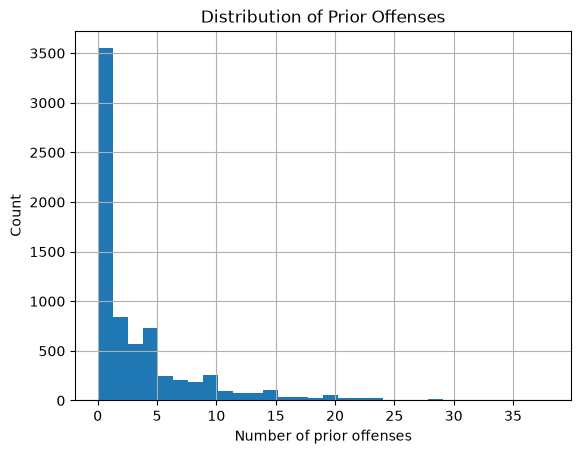

In [15]:
import matplotlib.pyplot as plt

#Histogram of priors offenses
df['priors_count'].hist(bins=30)
plt.xlabel('Number of prior offenses')
plt.ylabel('Count')
plt.title('Distribution of Prior Offenses')
plt.show()

In [16]:
#Cross-tabulation of COMPAS risk score and two-year recidivism
pd.crosstab(df['score_text'], df['two_year_recid'], normalize='index')

two_year_recid,0,1
score_text,,
High,0.286529,0.713471
Low,0.687965,0.312035
Medium,0.459770,0.540230


In [17]:
#Include race in the cross-tabulation(African-American & Caucasian).
#Limited scope to African-American and Caucasian races because of significant sample size difference with other races.
for race in ['African-American', 'Caucasian']:
    subset = df[df['race'] == race]
    print(f"\n{race}:")
    print(pd.crosstab(subset['score_text'], subset['two_year_recid'], normalize='index'))


African-American:
two_year_recid         0         1
score_text                        
High            0.277073  0.722927
Low             0.650460  0.349540
Medium          0.453438  0.546562

Caucasian:
two_year_recid         0         1
score_text                        
High            0.293478  0.706522
Low             0.711875  0.288125
Medium          0.463668  0.536332


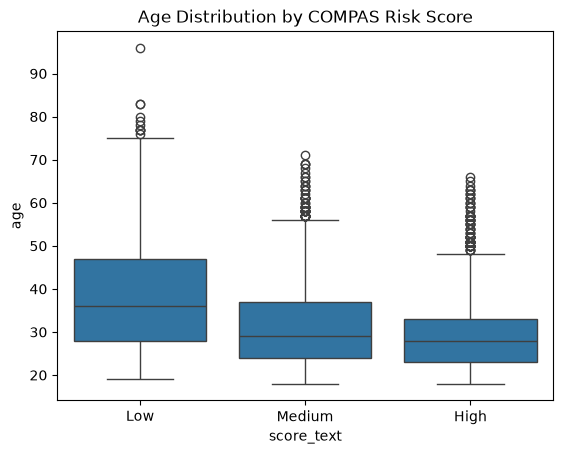

In [18]:
import seaborn as sns

#boxplot visualization of age distribution by COMPAS risk score
sns.boxplot(x='score_text', y='age', data=df, order=['Low', 'Medium', 'High'])
plt.title('Age Distribution by COMPAS Risk Score')
plt.show()

In [19]:
for race in ['African-American', 'Caucasian']:
    subset = df[df['race'] == race]
    print(f"\n{race}:")
    print(pd.crosstab(subset['two_year_recid'], subset['score_text'], normalize='index'))


African-American:
score_text          High       Low    Medium
two_year_recid                              
0               0.158217  0.551532  0.290251
1               0.389795  0.279853  0.330352

Caucasian:
score_text          High       Low    Medium
two_year_recid                              
0               0.054435  0.765457  0.180108
1               0.201863  0.477226  0.320911


In [20]:
df.groupby('race')['two_year_recid'].mean()

race
African-American    0.514340
Asian               0.281250
Caucasian           0.393643
Hispanic            0.364207
Native American     0.555556
Other               0.352785
Name: two_year_recid, dtype: float64